In [2]:
import pandas as pd
from datasets import load_dataset, \
    concatenate_datasets

from transformers import AutoTokenizer

/home/tb/Documents/UNIBZ_research/PhD/CodeWorks/NL_BSE_challnege/NLBSE2026/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
ds = load_dataset('NLBSE/nlbse25-code-comment-classification')

In [4]:
ds["java_train"][1]

{'index': 1,
 'class': 'Abfss.java',
 'comment_sentence': 'this impl delegates to the old filesystem',
 'partition': 0,
 'combo': 'this impl delegates to the old filesystem | Abfss.java',
 'labels': [0, 0, 1, 0, 0, 0, 0]}

In [37]:
langs = ['java', 'python', 'pharo']
labels = {
    'java': ['summary', 'Ownership', 'Expand', 'usage', 'Pointer', 'deprecation', 'rational'],
    'python': ['Usage', 'Parameters', 'DevelopmentNotes', 'Expand', 'Summary'],
    'pharo': ['Keyimplementationpoints', 'Example', 'Responsibilities', 'Classreferences', 'Intent', 'Keymessages', 'Collaborators']
}

def split_list_into_columns(row, lang):
    values_list = row['labels']  # Replace 'values' with your actual column name
    dict = {}
    for key in labels[lang]:
        dict[key] = values_list[labels[lang].index(key)]

    return dict

def print_labels(data, lang):
    for label in labels[lang]:
        group = data.groupby(label).count()
        print("label " + label)
        print("positive", group["class"][1], ",negative", group["class"][0], "--- %", (group["class"][1]/(group["class"][1]+group["class"][0]))*100)
        print("number of augments | 10%", (group["class"][0]-group["class"][1])*0.1,
              "| 25%", (group["class"][0]-group["class"][1])*0.25,
              "| 50%", (group["class"][0]-group["class"][1])*0.5,
              "| 75%", (group["class"][0]-group["class"][1])*0.75,
              "| 100%", (group["class"][0]-group["class"][1]))
        print('*'*40)

java = concatenate_datasets([ds["java_train"]]).map(lambda row: split_list_into_columns(row, "java")).to_pandas()
python = concatenate_datasets([ds["python_train"]]).map(lambda row: split_list_into_columns(row, "python")).to_pandas()
pharo = concatenate_datasets([ds["pharo_train"]]).map(lambda row: split_list_into_columns(row, "pharo")).to_pandas()


In [40]:
def balance_labels(ds,lang, target_ratio, tol=0.1, max_iter=10000):
    """
    Balance positive instances per label to reach a target ratio with a tolerance.
    
    Parameters:
    - d: dict of {label: {'positive': int, 'negative': int}}
    - target_ratio: desired positive/negative ratio
    - tol: allowed relative error (default 0.1 → 10%)
    - max_iter: maximum iterations to prevent infinite loops
    
    Returns:
    - dict with final positive and negative counts
    """
    labels = {
        'java': ['summary', 'Ownership', 'Expand', 'usage', 'Pointer', 'deprecation', 'rational'],
        'python': ['Usage', 'Parameters', 'DevelopmentNotes', 'Expand', 'Summary'],
        'pharo': ['Keyimplementationpoints', 'Example', 'Responsibilities', 'Classreferences', 'Intent', 'Keymessages', 'Collaborators']
    }

    d = {}
    for l in labels[lang]:
        group = ds.groupby(l).count()
        if l not in d.keys():
            d[l] = {"positive":group["class"][1], 
                    "negative": group["class"][0]}
            
    labels = list(d.keys())
    added_pos = {l: 0 for l in labels}
    changed = True
    iteration = 0
    
    while changed and iteration < max_iter:
        changed = False
        iteration += 1
        
        for l in labels:
            P = d[l]['positive'] + added_pos[l]
            N = d[l]['negative'] + sum(added_pos[other] for other in labels if other != l)
            current_ratio = P / N
            
            # Acceptable range considering tolerance
            if current_ratio < target_ratio * (1 - tol):
                added_pos[l] += 1
                changed = True
    
    if iteration == max_iter:
        print("Warning: maximum iterations reached. Result may not fully meet target ratio.")
    
    # Compute final counts
    result = {}
    resultL = []
    for l in labels:
        final_pos = d[l]['positive'] + added_pos[l]
        final_neg = d[l]['negative'] + sum(added_pos[other] for other in labels if other != l)
        result[l] = {'add': added_pos[l],'positive': final_pos, 'negative': final_neg}
        resultL.append(added_pos[l])
    
    return result,resultL

# Example usage
target_ratio = 0.15
balanced,balancedl = balance_labels(java,'java', target_ratio)
print(balancedl)
for l in labels['java']:
    print(l)
    print(balanced[l])
    print('*'*40)


[0, 1349, 1107, 0, 712, 1499, 1305]
summary
{'add': 0, 'positive': np.int64(3610), 'negative': np.int64(9976)}
****************************************
Ownership
{'add': 1349, 'positive': np.int64(1616), 'negative': np.int64(11970)}
****************************************
Expand
{'add': 1107, 'positive': np.int64(1616), 'negative': np.int64(11970)}
****************************************
usage
{'add': 0, 'positive': np.int64(2093), 'negative': np.int64(11493)}
****************************************
Pointer
{'add': 712, 'positive': np.int64(1616), 'negative': np.int64(11970)}
****************************************
deprecation
{'add': 1499, 'positive': np.int64(1616), 'negative': np.int64(11970)}
****************************************
rational
{'add': 1305, 'positive': np.int64(1616), 'negative': np.int64(11970)}
****************************************


In [8]:
print_labels(java, "java")

label summary
positive 3610 ,negative 4004 --- % 47.41266088783819
number of augments | 10% 39.400000000000006 | 25% 98.5 | 50% 197.0 | 75% 295.5 | 100% 394
****************************************
label Ownership
positive 267 ,negative 7347 --- % 3.5066981875492518
number of augments | 10% 708.0 | 25% 1770.0 | 50% 3540.0 | 75% 5310.0 | 100% 7080
****************************************
label Expand
positive 509 ,negative 7105 --- % 6.685053848174416
number of augments | 10% 659.6 | 25% 1649.0 | 50% 3298.0 | 75% 4947.0 | 100% 6596
****************************************
label usage
positive 2093 ,negative 5521 --- % 27.488836354084583
number of augments | 10% 342.8 | 25% 857.0 | 50% 1714.0 | 75% 2571.0 | 100% 3428
****************************************
label Pointer
positive 904 ,negative 6710 --- % 11.872865773574993
number of augments | 10% 580.6 | 25% 1451.5 | 50% 2903.0 | 75% 4354.5 | 100% 5806
****************************************
label deprecation
positive 117 ,negative 749

In [9]:
print_labels(python, "python")

label Usage
positive 578 ,negative 1306 --- % 30.67940552016985
number of augments | 10% 72.8 | 25% 182.0 | 50% 364.0 | 75% 546.0 | 100% 728
****************************************
label Parameters
positive 572 ,negative 1312 --- % 30.36093418259023
number of augments | 10% 74.0 | 25% 185.0 | 50% 370.0 | 75% 555.0 | 100% 740
****************************************
label DevelopmentNotes
positive 210 ,negative 1674 --- % 11.146496815286625
number of augments | 10% 146.4 | 25% 366.0 | 50% 732.0 | 75% 1098.0 | 100% 1464
****************************************
label Expand
positive 343 ,negative 1541 --- % 18.205944798301484
number of augments | 10% 119.80000000000001 | 25% 299.5 | 50% 599.0 | 75% 898.5 | 100% 1198
****************************************
label Summary
positive 347 ,negative 1537 --- % 18.418259023354562
number of augments | 10% 119.0 | 25% 297.5 | 50% 595.0 | 75% 892.5 | 100% 1190
****************************************


In [10]:
print_labels(pharo, "pharo")

label Keyimplementationpoints
positive 178 ,negative 1120 --- % 13.713405238828969
number of augments | 10% 94.2 | 25% 235.5 | 50% 471.0 | 75% 706.5 | 100% 942
****************************************
label Example
positive 547 ,negative 751 --- % 42.14175654853621
number of augments | 10% 20.400000000000002 | 25% 51.0 | 50% 102.0 | 75% 153.0 | 100% 204
****************************************
label Responsibilities
positive 245 ,negative 1053 --- % 18.875192604006163
number of augments | 10% 80.80000000000001 | 25% 202.0 | 50% 404.0 | 75% 606.0 | 100% 808
****************************************
label Classreferences
positive 46 ,negative 1252 --- % 3.5439137134052388
number of augments | 10% 120.60000000000001 | 25% 301.5 | 50% 603.0 | 75% 904.5 | 100% 1206
****************************************
label Intent
positive 151 ,negative 1147 --- % 11.633281972265024
number of augments | 10% 99.60000000000001 | 25% 249.0 | 50% 498.0 | 75% 747.0 | 100% 996
*********************************

In [11]:
import pandas as pd
from tqdm import tqdm
import numpy as np

data = pd.concat([ds["java_train"].to_pandas(), ds["python_train"].to_pandas(), ds["pharo_train"].to_pandas()])
data["len_tokens"] = None
data["sumLabel"] = None

len(data)
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

pbar = tqdm(total=len(data), desc="adding tokens length...")

for index, row in data.iterrows():
    input = row["combo"]
    tokens = tokenizer.encode(input)
    len_tokens = len(tokens)
    data.loc[index, "len_tokens"] = len_tokens
    data.loc[index, "sumLabel"] = sum(row["labels"])
    pbar.update(1)

pbar.close()

data

adding tokens length...: 100%|██████████| 10796/10796 [00:06<00:00, 1628.13it/s]


,index,class,comment_sentence,partition,combo,labels,len_tokens,sumLabel
0,0,Abfss.java,azure blob file system implementation of abstr...,0,azure blob file system implementation of abstr...,"[1, 0, 0, 0, 0, 0, 0]",31,1
1,1,Abfss.java,this impl delegates to the old filesystem,0,this impl delegates to the old filesystem | Ab...,"[0, 0, 1, 0, 0, 0, 0]",19,1
2,2,AbstractContractGetFileStatusTest.java,test getfilestatus and related listing operati...,0,test getfilestatus and related listing operati...,"[1, 0, 0, 0, 0, 0, 0]",22,1
3,11,AbstractContractGetFileStatusTest.java,path filter which only expects paths whose fin...,0,path filter which only expects paths whose fin...,"[0, 0, 1, 0, 0, 0, 0]",40,1
4,15,AbstractContractGetFileStatusTest.java,a filesystem filter which exposes the protecte...,0,a filesystem filter which exposes the protecte...,"[0, 0, 1, 0, 0, 0, 0]",16,1
...,...,...,...,...,...,...,...,...
1293,1839,WAUpTimeTracker,access the timestamp when the image booted as ...,0,access the timestamp when the image booted as ...,"[0, 0, 1, 0, 0, 1, 1]",16,3
1294,1842,WAUpTimeTracker,access the duration how long ago the image boo...,0,access the duration how long ago the image boo...,"[0, 0, 1, 0, 0, 1, 1]",18,3
1295,1845,WAUpTimeTracker,at system startup the imageboottime is re set ...,0,at system startup the imageboottime is re set ...,"[0, 0, 1, 0, 0, 1, 1]",19,3
1296,1846,WAUrlAttribute,waurlattribute represents a url attribute.,0,waurlattribute represents a url attribute. | W...,"[0, 0, 0, 0, 1, 0, 0]",15,1


Min: 5
Max: 526
Average: 25.18
Median: 21.00


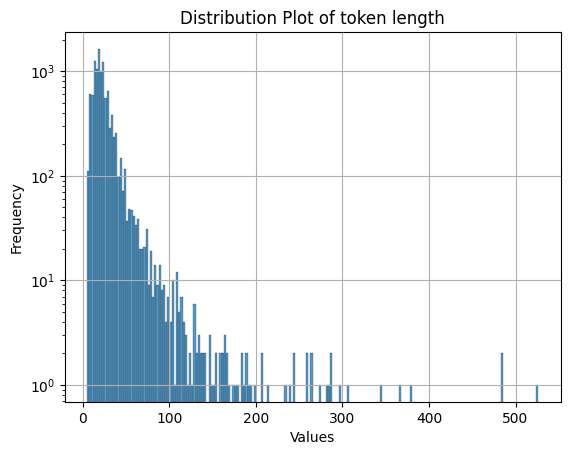

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
list_token_length = data['len_tokens']
min_value = np.min(list_token_length)
max_value = np.max(list_token_length)
average = np.mean(list_token_length)
median = np.median(list_token_length)

print(f"Min: {min_value}")
print(f"Max: {max_value}") # apparently, one single input is longer than 512 and is truncated - I dont see an issue there
print(f"Average: {average:.2f}")
print(f"Median: {median:.2f}")

sns.histplot(list_token_length, kde=False)
plt.title("Distribution Plot of token length")
plt.yscale('log') # Adding a log scale at the y-axis to give more visibility to the long inputs
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Token indices sequence length is longer than the specified maximum sequence length for this model (526 > 512). Running this sequence through the model will result in indexing errors



 Java dataset:
Min: 7
Max: 526
Average: 28.22
Median: 22.00


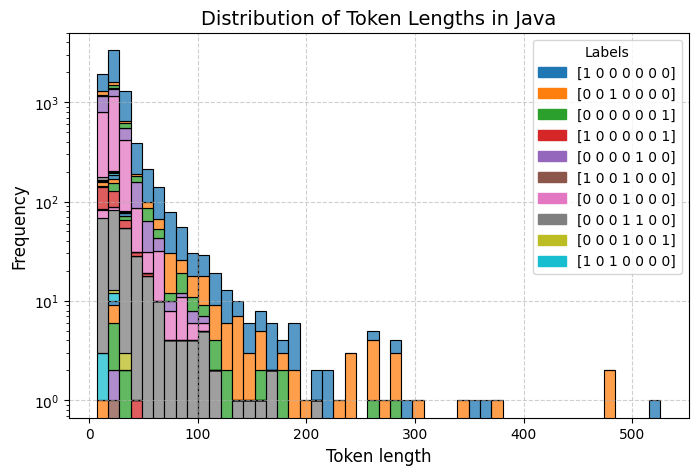


 Python dataset:
Min: 5
Max: 45
Average: 15.07
Median: 15.00


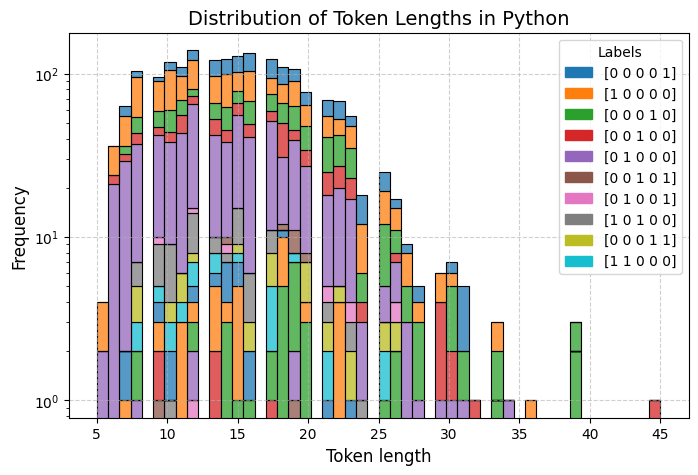


 Pharo dataset:
Min: 6
Max: 104
Average: 20.55
Median: 19.00


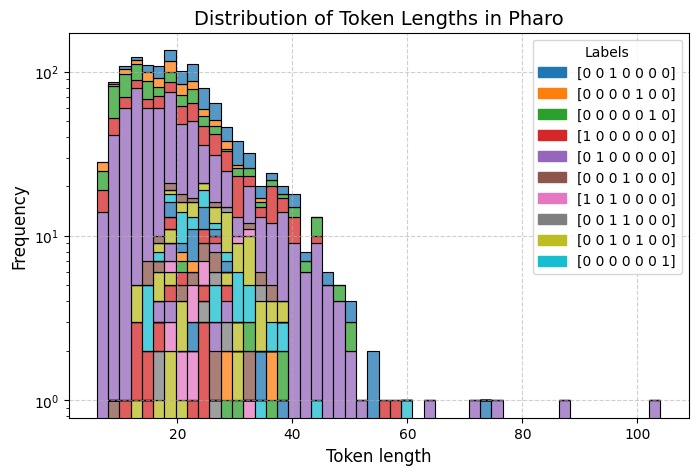

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

datasets = {
    "Java": ds["java_train"].to_pandas(),
    "Python": ds["python_train"].to_pandas(),
    "Pharo": ds["pharo_train"].to_pandas(),
}

for lang, df in datasets.items():
    # Compute token length and sum of labels
    df["len_tokens"] = df["combo"].apply(lambda x: len(tokenizer.encode(x)))
    df["sumLabel"] = df["labels"].apply(sum)
    df['hue']=df["labels"].apply(str)

    # Stats
    min_value = df["len_tokens"].min()
    max_value = df["len_tokens"].max()
    avg_value = df["len_tokens"].mean()
    median_value = df["len_tokens"].median()

    print(f"\n {lang} dataset:")
    print(f"Min: {min_value}")
    print(f"Max: {max_value}")
    print(f"Average: {avg_value:.2f}")
    print(f"Median: {median_value:.2f}")

    # Plot distribution colored by label count
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x="len_tokens", hue="hue", bins=50, kde=False, multiple="stack",
    palette="tab10",
    legend=True)
    plt.title(f"Distribution of Token Lengths in {lang}", fontsize=14)
    plt.yscale('log')  # better visibility
    plt.xlabel("Token length", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    handles = [Patch(color=c, label=l) for l, c in zip(df["hue"].unique(), sns.color_palette("tab10"))]
    plt.legend(handles=handles, title="Labels", loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


Number of observations with all-zero labels: 0


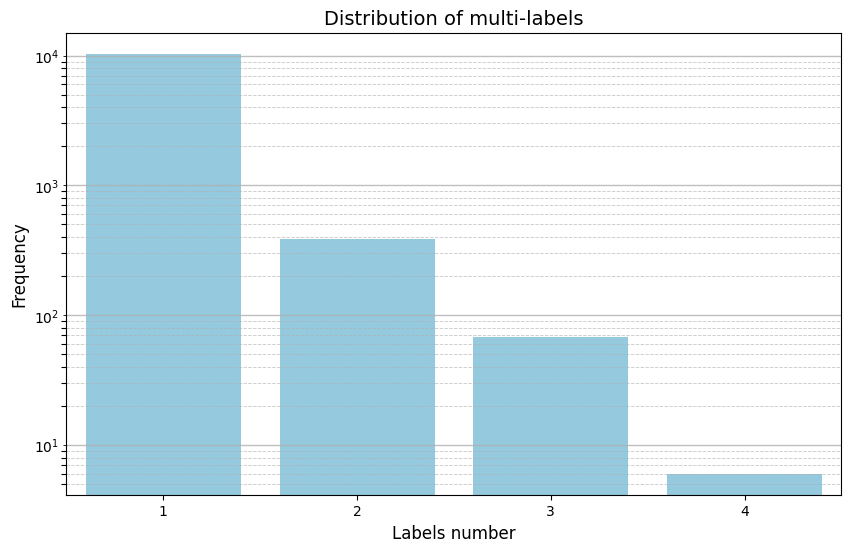

In [14]:
from matplotlib.ticker import LogLocator
num_zero_labels = (data["sumLabel"] == 0).sum()
print(f"Number of observations with all-zero labels: {num_zero_labels}")

list_length = data['sumLabel']

# Compute frequency of each token length
length_counts = pd.Series(list_length).value_counts().sort_index()

# Plot as bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=length_counts.index, y=length_counts.values, color="skyblue")

plt.title("Distribution of multi-labels", fontsize=14)
plt.xlabel("Labels number", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
# Log scale on y-axis
plt.yscale('log')

# Major ticks: powers of 10 (solid gridlines)
plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))
plt.grid(which="major", axis="y",linestyle="--", linewidth=0.65, alpha=0.65)

# Minor ticks: between powers of 10 (dashed gridlines)
plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10), numticks=10))
plt.grid(which="minor",axis="y", linestyle="-", linewidth=1, alpha=0.8)

plt.show()

In [15]:
def generate_weights(weighted_loss, data):

    if weighted_loss == "frequency":
        labels = data["labels"]
        labels_array = np.array(labels)
        class_counts = labels_array.sum(axis=0)
        total_samples = len(labels)
        class_frequencies = (class_counts/total_samples)*100
        result = []

        for i, freq in enumerate(class_frequencies):
            result.append(round(1/freq, 2))

        result = np.array(result)

        return class_frequencies #* (1 / np.sum(result))

    if weighted_loss == "ranked":
        labels = data["labels"]
        labels_array = np.array(labels)
        class_counts = labels_array.sum(axis=0)
        total_samples = len(labels)
        class_frequencies = (class_counts/total_samples)*100

        sorted_values = sorted(range(len(class_frequencies)), key=lambda x: class_frequencies[x], reverse=True)
        sorted_frequencies = sorted(class_frequencies)

        mapped_output = [0] * len(class_frequencies)
        for i, idx in enumerate(sorted_values):
            mapped_output[idx] = sorted_frequencies[i]

        return mapped_output


    # NO WEIGHTED LOSS
    return [1] * len(data[0]["labels"])

In [16]:
print(f"frequency: {generate_weights('frequency', ds['java_train'])}")
print(f"ranked: {generate_weights('ranked', ds['java_train'])}")
print(f"noweight: {generate_weights('no', ds['java_train'])}")

frequency: [47.41266089  3.50669819  6.68505385 27.48883635 11.87286577  1.53664303
  4.08458103]
ranked: [np.float64(1.5366430260047281), np.float64(27.488836354084583), np.float64(6.685053848174416), np.float64(3.5066981875492518), np.float64(4.084581034935645), np.float64(47.41266088783819), np.float64(11.872865773574993)]
noweight: [1, 1, 1, 1, 1, 1, 1]
